In [44]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

## 1

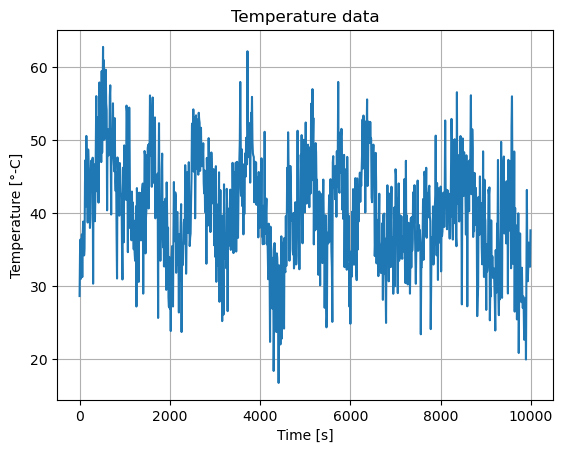

In [45]:
data = np.loadtxt("temperatures.dat", delimiter=",")

fs = 0.1
t = np.arange(0, len(data) / fs, 1 / fs)

plt.figure()
plt.plot(t, data)
plt.title("Temperature data")
plt.xlabel("Time [s]")
plt.ylabel("Temperature [°­C]")
plt.grid()
plt.show()

## 2

Since the sum is finite, the moving average filter is also a FIR filter, where all terms $x[n-i]$ have the coefficient $\frac{1}{N}$.

## 3

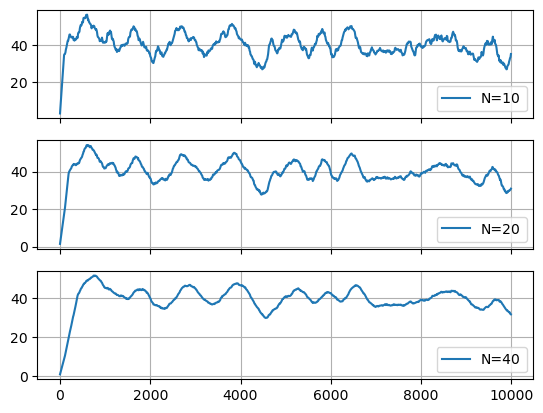

In [50]:
fig, ax = plt.subplots(3, 1, sharex=True)

for i, N in enumerate([10, 20, 40]):
    b = np.ones(N) / N
    a = [1]

    filtered_data = signal.lfilter(b, a, data)
    ax[i].plot(t, filtered_data, label="N={}".format(N))
    ax[i].grid()
    ax[i].legend()

$N=20$ looks good since it smooths out the noise while also keeping information such as the increase in temperature at the very end.

## 4

We assume that temperature can't fluctuate discontinuously. The moving average filter will therefore give a realistic estimate of the data and can be used in this case. The problem with the filter is that it has a time shift, but since you take that into account, it is a valid tool.

## 5

The filter is highly affected by transient distortion. The higher the value of $n$ used is, the larger the transient part will become.

## 6

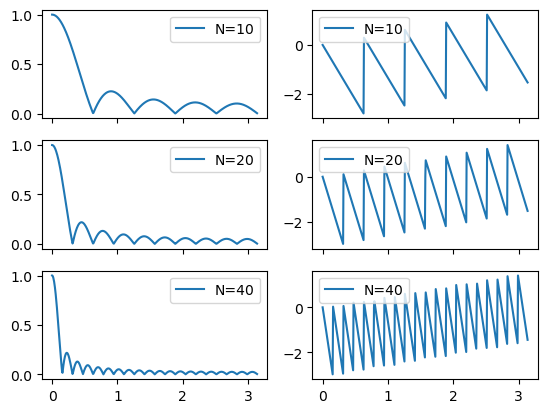

In [52]:
fig, ax = plt.subplots(3, 2, sharex=True)

for i, N in enumerate([10, 20, 40]):
    b = np.ones(N) / N
    a = [1]
    w, H = signal.freqz(b, a)

    ax[i,0].plot(w, np.abs(H), label="N={}".format(N))
    ax[i,1].plot(w, np.angle(H), label="N={}".format(N))
    ax[i,0].legend()
    ax[i,1].legend()

## 7